In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
escenario1 = pd.read_csv('lab2_escenario1.csv')
escenario2 = pd.read_csv('lab2_escenario2.csv')

def calcular_ganancia_fiel_al_robot(df):
    R = 0.0025
    Q = 0.0005
    P = 0.01
    
    k_list = []
    
    for i in range(len(df)):
        # Replicamos la lógica del controlador de Webots:
        # Si el robot está girando, P se reinicia. 
        # Si está avanzando, P sigue la lógica de Kalman.
        
        if df.loc[i, 'turning'] == 1:
            P = 0.05  # Este es el valor de reset que tienes en tu código
            K = 0.0   # Durante el giro no hay corrección de Kalman activa
        else:
            # 1. Predicción
            P_pred = P + Q
            # 2. Corrección (Ganancia)
            K = P_pred / (P_pred + R)
            # 3. Actualización de P para la siguiente iteración
            P = (1.0 - K) * P_pred
            
        k_list.append(K)
        
    df['K_real'] = k_list
    return df

# Aplicarlo a tus dos escenarios
escenario1 = calcular_ganancia_fiel_al_robot(escenario1)
escenario2 = calcular_ganancia_fiel_al_robot(escenario2)

In [3]:
escenario1 


,time,raw_ps0,raw_ps7,l_encoder,r_encoder,z_procesado,simple_filt,kalman_est,turning,decision,K_real
0,0.032,63.661986,69.983902,0.20096,0.20096,0.105621,0.105621,0.085309,0,forward,0.807692
1,0.064,67.792124,67.068430,0.29516,0.29516,0.106689,0.105834,0.095078,0,forward,0.501916
2,0.096,69.651024,65.047920,0.38936,0.38936,0.106915,0.106051,0.098826,0,forward,0.412427
3,0.128,62.822918,70.805016,0.48984,0.48984,0.106097,0.106060,0.100310,0,forward,0.379817
4,0.160,72.760208,64.940512,0.58404,0.58404,0.103341,0.105516,0.100200,0,forward,0.367015
...,...,...,...,...,...,...,...,...,...,...,...
1915,61.312,64.637943,70.013338,146.60032,141.96568,0.106657,0.106342,0.103025,0,forward,0.358258
1916,61.344,67.493049,62.362705,146.69452,142.05988,0.108480,0.106770,0.103740,0,forward,0.358258
1917,61.376,65.110426,68.214446,146.79500,142.15408,0.104138,0.106243,0.102602,0,forward,0.358258
1918,61.408,65.801765,72.099748,146.88920,142.24828,0.105194,0.106034,0.102291,0,forward,0.358258


In [4]:
escenario2

,time,raw_ps0,raw_ps7,l_encoder,r_encoder,z_procesado,simple_filt,kalman_est,turning,decision,K_real
0,0.032,63.661986,69.983902,459.77764,477.84520,0.105621,0.105621,0.085309,0,forward,0.807692
1,0.064,67.792124,67.068430,459.87184,477.93940,0.106689,0.105834,0.095078,0,forward,0.501916
2,0.096,69.651024,65.047920,459.96604,478.03360,0.106915,0.106051,0.098826,0,forward,0.412427
3,0.128,62.822918,70.805016,460.06024,478.13408,0.106097,0.106060,0.100350,0,forward,0.379817
4,0.160,72.760208,64.940512,460.16072,478.22828,0.103341,0.105516,0.100184,0,forward,0.367015
...,...,...,...,...,...,...,...,...,...,...,...
1884,60.320,191.171697,139.925347,601.31628,615.06320,0.059003,0.059555,0.074492,1,forward,0.000000
1885,60.352,204.126657,129.632491,601.23464,615.14484,0.056313,0.058907,0.074492,1,forward,0.000000
1886,60.384,198.649259,125.832244,601.15300,615.22648,0.057420,0.058609,0.074492,1,forward,0.000000
1887,60.416,200.549345,110.711525,601.07136,615.30812,0.057031,0.058294,0.074492,1,forward,0.000000


In [5]:
escenario1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1920 non-null   float64
 1   raw_ps0      1920 non-null   float64
 2   raw_ps7      1920 non-null   float64
 3   l_encoder    1920 non-null   float64
 4   r_encoder    1920 non-null   float64
 5   z_procesado  1920 non-null   float64
 6   simple_filt  1920 non-null   float64
 7   kalman_est   1920 non-null   float64
 8   turning      1920 non-null   int64  
 9   decision     1920 non-null   str    
 10  K_real       1920 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 165.1 KB


In [6]:
# Escenario 1
print("Desviación Escenario 1:", escenario1['raw_ps0'].std())

# Escenario 2
print("Desviación Escenario 2:", escenario2['raw_ps0'].std())

Desviación Escenario 1: 25.084729073141318
Desviación Escenario 2: 26.969692020825747


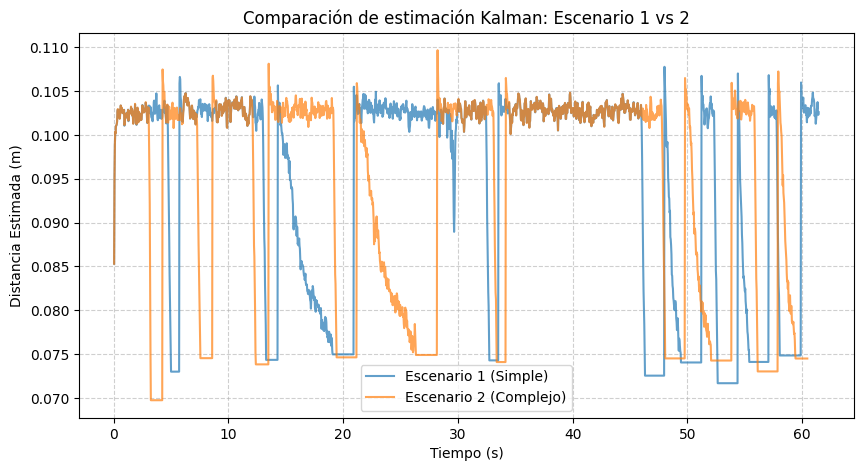

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(escenario1['time'], escenario1['kalman_est'], label='Escenario 1 (Simple)', alpha=0.7)
plt.plot(escenario2['time'], escenario2['kalman_est'], label='Escenario 2 (Complejo)', alpha=0.7)

# Etiquetas de los ejes
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia Estimada (m)')

# Título y leyenda
plt.title('Comparación de estimación Kalman: Escenario 1 vs 2')
plt.legend()

# Añadir rejilla para facilitar el análisis
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [8]:
def graficar_señales(df, escenario_nombre):
    plt.figure(figsize=(10, 5))
    # Colores definidos para alta visibilidad: Rojo suave, Azul vibrante, Negro sólido
    plt.plot(df['time'], df['z_procesado'], label='Cruda', color='#FF9999', alpha=0.6, linewidth=1)
    plt.plot(df['time'], df['simple_filt'], label='Filtro Simple', color='#FF7F0E', linestyle='--', linewidth=1.5)
    plt.plot(df['time'], df['kalman_est'], label='Kalman (Estimada)', color='#2CA02C', linewidth=2)
    plt.title(f'Comparación de Señales: {escenario_nombre}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Distancia (m)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def graficar_navegacion(df, escenario_nombre):
    plt.figure(figsize=(10, 2))
    # Azul oscuro para que destaque sobre el fondo blanco
    plt.step(df['time'], df['turning'], label='Estado (0=Fwd, 1=Turn)', color='#1F77B4', where='post')
    plt.title(f'Máquina de Estados: {escenario_nombre}')
    plt.xlabel('Tiempo (s)')
    plt.ylim(-0.1, 1.1)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def plot_ganancia(df, nombre):
    plt.figure(figsize=(10, 4))
    # Morado intenso para diferenciar de las otras gráficas
    plt.plot(df['time'], df['K_real'], label='Ganancia Kalman (K)', color='#9467BD', linewidth=2)
    plt.title(f'Evolución de la Ganancia K: {nombre}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Valor de K')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def graficar_comparativa_final(df1, df2):
    plt.figure(figsize=(10, 5))
    # Comparamos la estimación de Kalman en ambos escenarios
    plt.plot(df1['time'], df1['kalman_est'], label='Kalman (Escenario 1)', color='#2CA02C', alpha=0.6)
    plt.plot(df2['time'], df2['kalman_est'], label='Kalman (Escenario 2)', color='#D62728', alpha=0.6)
    plt.title('Comparativa de Robustez: Escenario 1 vs Escenario 2')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Distancia Estimada (m)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

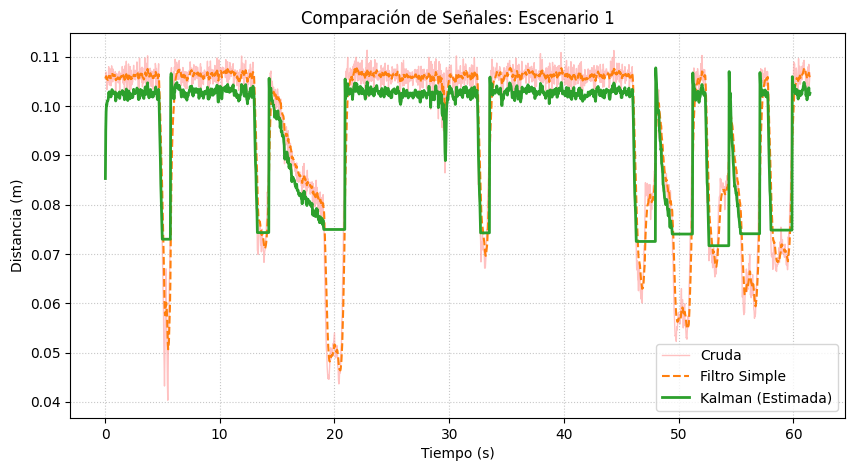

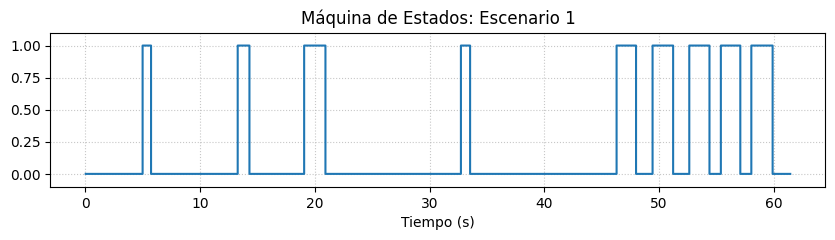

In [9]:
# Escenario 1
graficar_señales(escenario1, "Escenario 1")
graficar_navegacion(escenario1, "Escenario 1")



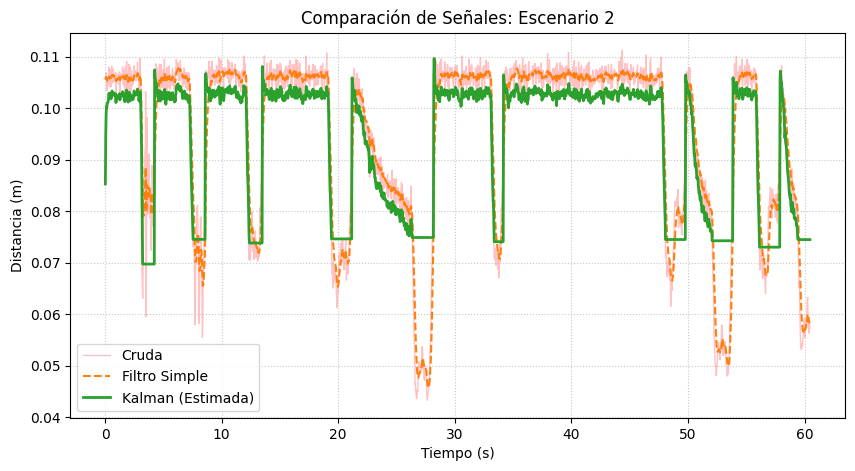

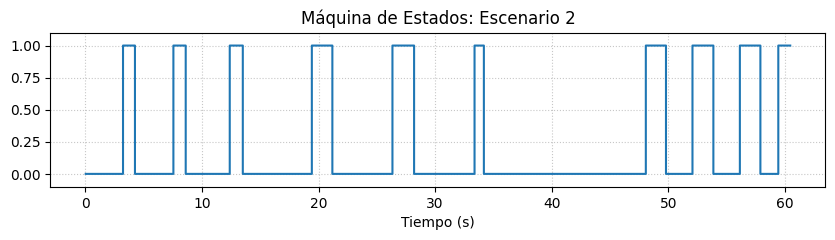

In [10]:
# Escenario 2
graficar_señales(escenario2, "Escenario 2")
graficar_navegacion(escenario2, "Escenario 2")

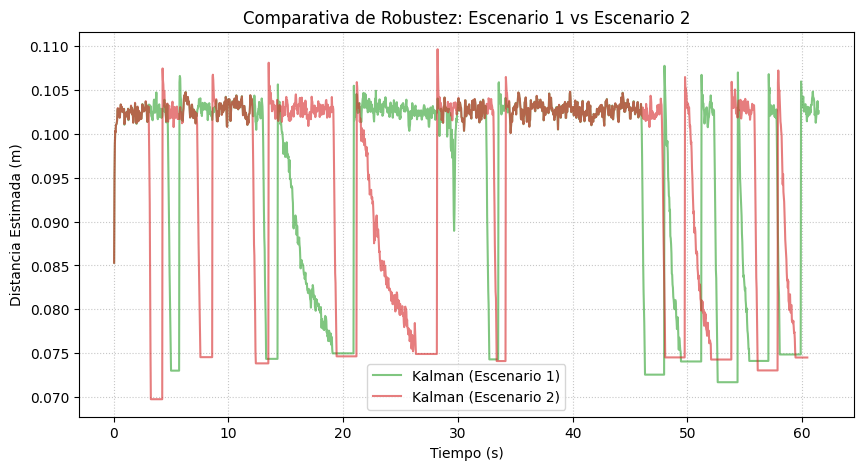

In [11]:
# Comparativa final
graficar_comparativa_final(escenario1, escenario2)